# 📊 FinDataMining
Notebook 02: **Transformación de Datos**

---

## Preliminares

In [1]:
import pandas as pd
import numpy as np
from src.config import data_folder
%load_ext autoreload
%autoreload 2
from src.clean_transform import corregir_anomalias
from src.transform import *

In [2]:
# Abrir archivo raw_data
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")

# Se asegura el ordenamiento por fecha
df = df.sort_values(by='Date').reset_index(drop=True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11390 entries, 0 to 11389
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Date                         11390 non-null  datetime64[ns]
 1   Ticker                       11390 non-null  str           
 2   Close                        11390 non-null  float64       
 3   Open                         11390 non-null  float64       
 4   Volume                       11390 non-null  float64       
 5   DateAdded                    6721 non-null   str           
 6   Sector                       11390 non-null  str           
 7   Industry                     11390 non-null  str           
 8   TotalRevenue                 11390 non-null  float64       
 9   GrossProfit                  10537 non-null  float64       
 10  OperatingIncome              11390 non-null  float64       
 11  NetIncome                    11390 non-null  float64

## Limpieza de Datos

In [3]:
# Limpiar cadenas en Industry y Sector: 
# sin espacios, primer letra en mayuscula y reemplaza el simbolo '&' por 'And'
df['Industry'] = df['Industry'].apply(limpiar_cadenas)
df['Sector'] = df['Sector'].apply(limpiar_cadenas)

# Ver cambios
df[['Industry', 'Sector']].head()

,Industry,Sector
0,Home Improvement Retail,Consumer Cyclical
1,Apparel Retail,Consumer Cyclical
2,Discount Stores,Consumer Defensive
3,Apparel Retail,Consumer Cyclical
4,Software Application,Technology


* Se convierten Sector y Industry a variable tipo *category*:

In [4]:
df['Sector'] = df['Sector'].astype('category')
df['Industry'] = df['Industry'].astype('category')

# Valores unicos en Sector
df['Sector'].value_counts()

Sector
Consumer Cyclical         2330
Industrials               2223
Technology                1854
Healthcare                1140
Financial Services         901
Consumer Defensive         861
Basic Materials            614
Energy                     583
Communication Services     427
Real Estate                251
Utilities                  206
Name: count, dtype: int64

In [5]:
# Valores unicos en Industry
df['Industry'].value_counts()

Industry
Specialty Industrial Machinery           362
Semiconductors                           298
Software Application                     288
Information Technology Services          273
Engineering And Construction             263
                                        ... 
Utilities Diversified                     23
Luxury Goods                              22
Solar                                     22
Utilities Independent Power Producers     22
Lumber And Wood Production                21
Name: count, Length: 116, dtype: int64

* Para mejorar la visualización de los datos, se expresan las columnas financieras y volumen en millones:

In [6]:
df = columnas_en_millones(df)

### Corrección de anomalías

#### Error de importes en Balance General
Se analiza el siguiente registro, el cual muestra valores extremadamente elevados en el Balance:

In [7]:
# Caso 1: Error de importes en el Galance General
condicion_1 = df[(df['Ticker'] == 'IIIN') & (df['Date'] == '2021-12-01')]

# Mostrar el registro
print(condicion_1.T)

                                            2498
Date                         2021-12-01 00:00:00
Ticker                                      IIIN
Close                                  28.253134
Open                                    31.38222
Volume                                    7.3179
DateAdded                                    NaN
Sector                               Industrials
Industry                       Metal Fabrication
TotalRevenue                             171.258
GrossProfit                               39.919
OperatingIncome                           32.598
NetIncome                                 25.152
EBITDA                                       NaN
BasicAverageShares                        19.344
CashAndCashEquivalents                   89884.0
CurrentDebt                                  NaN
LongTermDebt                                 NaN
TotalDebt                                    NaN
StockholdersEquity                      302038.0
TotalAssets         

* Se observa una desconexión en los valores del Balance General, están multiplicados por 1.000.
* El caso se detecto ya que arrojaba valores extremos en las métricas.

Se corrigirá dividiendo las columnas afectadas por 1.000.

#### Anomalías de signo: 

Las siguientes variables no pueden ser negativas:
* `TotalRevenue`
* `CurrentDebt`
* `LongTermDebt`
* `DepreciationAndAmortization`

In [8]:
# Caso 2:  TotalRevenue negativo
condicion_2 = df['TotalRevenue'] < 0

# Mostrar los registros
cols_a_visualizar_2 = ['Ticker', 'Date', 'TotalRevenue', 'OperatingIncome']
anomalias = df.loc[condicion_2, cols_a_visualizar_2]
print(anomalias)
print("Cantidad de casos:", len(anomalias))

     Ticker       Date  TotalRevenue  OperatingIncome
587    AVNT 2021-03-01     -30.20000       -12.700000
754     ALB 2021-03-01   -1790.31392      -114.758843
791     XPO 2021-03-01   -1093.00000        14.000000
2099    EMR 2021-12-01    -357.00000      -206.000000
2595    XPO 2022-03-01   -2243.00000      -189.000000
2673   FTNT 2022-03-01   -1415.00000       213.700000
2872    BHF 2022-03-01    -150.00000      2266.000000
4084      J 2022-12-01   -1258.70300       -69.426000
4758    CNA 2023-03-01   -3542.00000     -4648.000000
4832    BAX 2023-03-01    -704.00000      -285.000000
4923     GE 2023-03-01  -12134.00000      4010.000000
4965    BHF 2023-03-01    -127.00000        40.000000
5084    NGL 2023-06-01    -967.05000        65.932000
5540    WDC 2023-09-01   -3391.00000        93.000000
6208   OTIS 2023-12-01   -3543.00000      -516.000000
6352      J 2023-12-01   -1212.28200      -120.924000
6495   NDAQ 2024-03-01    -522.00000       481.000000
6603    FTV 2024-03-01    -5

* No se puede concluir que se traten de alteraciones de signo en el parseo de datos de simFin. Se observa en 2 casos que el valor absoluto de `TotalRevenue` es mayor que `OperatingIncome`, es imposible que los resultados sean mayores que las ventas.

Se opta por asignar todos estos valores anómalos a NaN.

#### Casos de deuda negativa: 
Se calcula el Pasivo Implícito, que surge de aplicar la ecuación contable fundamental `Activo` = `Pasivo` + `Patrimonio Neto`

In [9]:
# Caso 3:  Deuda negativa
condicion_3 = (df['CurrentDebt'] < 0) | (df['LongTermDebt'] < 0)

# Calcular el Pasivo Implícito
df['PasivoImplicito'] = df['TotalAssets'] - df['StockholdersEquity']

# Ver registros
cols_a_visualizar_3 = ['Ticker', 'Date', 'TotalDebt', 'CurrentDebt', 'LongTermDebt', 'PasivoImplicito']
anomalias = df.loc[condicion_3, cols_a_visualizar_3]
print(anomalias)
print("Cantidad de casos:", len(anomalias))

     Ticker       Date  TotalDebt  CurrentDebt  LongTermDebt  PasivoImplicito
3845    IEP 2022-09-01        NaN     -746.000      7134.000        15991.000
4218    IEP 2022-12-01        NaN     -745.000      7127.000        16908.000
6951   STLD 2024-03-01        NaN      459.987     -3286.537          171.287
7103   STLD 2024-06-01        NaN      425.696     -3570.028         -203.283
8004   STLD 2024-12-01        NaN      882.013     -3997.348         -218.698
8935    TXN 2025-03-01        NaN      750.000    -28049.000       -22289.000
Cantidad de casos: 6


* Se observa que la ecuación contable fundamental no se cumple. 

Se decide eliminar estos registros "tóxicos" del dataset.

#### Negativos en `DepreciationAndAmortization`: 

Se analizan los casos considerando la ecuación `EBITDA` = `OperatingIncome` + `DepreciationAndAmortization`, separando los registros según provengan de `yfinance` o de `simFin`:

In [10]:
# Caso 4:  Depreciación y Amortización negativa de yfinance
condicion_4 = (df['DepreciationAndAmortization'] < 0) & (df['FinancialsSource']=='yfinance')

# Ver registros
cols_a_visualizar_4 = ['Ticker', 'Date', 'DepreciationAndAmortization', 'EBITDA', 'OperatingIncome', 'FinancialsSource']
anomalias = df.loc[condicion_4, cols_a_visualizar_4]
print(anomalias)
print("Cantidad de casos:", len(anomalias))

      Ticker       Date  DepreciationAndAmortization  EBITDA  OperatingIncome  \
11013    GME 2026-06-01                         -0.3   144.9            144.9   

      FinancialsSource  
11013         yfinance  
Cantidad de casos: 1


* En este caso se observa que el valor implicito de `DepreciationAndAmortization` es igual a cero (EBITDA = OperatingIncome).
El valor de -0.3 pudo haberse tratado de un pequeño "ajuste contable", $300.000 dólares para una compañia del tamaño de `GameStop` es contablemente irrelevante. 

Se reemplazará el valor por cero.

In [11]:
# # Caso 5: Depreciación y Amortización negativa de simFin
condicion_5 = (df['DepreciationAndAmortization'] < 0) & (df['FinancialsSource']=='simFin')

# Ver registros
anomalias = df.loc[condicion_5, cols_a_visualizar_4] # mismas columnas que el caso anterior
print(anomalias)
print("Cantidad de casos:", len(anomalias))

     Ticker       Date  DepreciationAndAmortization  EBITDA  OperatingIncome  \
0        HD 2020-09-01                     -519.000     NaN         6067.000   
3      BURL 2020-09-01                      -54.404     NaN          -81.224   
6       TGT 2020-09-01                     -542.000     NaN         2300.000   
7       ADI 2020-09-01                     -107.077     NaN          450.954   
8        DY 2020-09-01                      -44.129     NaN           54.482   
...     ...        ...                          ...     ...              ...   
9743   CASY 2025-09-01                     -107.443     NaN          155.574   
9815   AVGO 2025-09-01                     -506.000     NaN         5915.000   
9846   LULU 2025-09-01                       -1.630     NaN          438.625   
9927   ADBE 2025-09-01                      -41.000     NaN         2109.000   
9931   ORCL 2025-09-01                     -544.000     NaN         5191.000   

     FinancialsSource  
0              

* `simFin` utiliza signo negativo para esta columna, lo cual es incorrecto. 

Dichos valores serán convertidos a positivos.

In [12]:
# Se aplican los cambios mencionados
df_clean = corregir_anomalias(df)

# Se elimina la columna calculada 'PasivoImplicito'
df_clean = df_clean.drop(columns= 'PasivoImplicito')

## Tratamiento Inicial de Missings

In [13]:
# Ver incidencia de missings
mostrar_missings(df_clean)

TotalDebt                      0.835383
FreeCashFlow                   0.834153
EBITDA                         0.833802
DepreciationAndAmortization    0.463194
DateAdded                      0.409961
CurrentDebt                    0.237439
GrossProfit                    0.074930
LongTermDebt                   0.056044
CurrentAssets                  0.048050
CurrentLiabilities             0.047786
CapitalExpenditure             0.027231
BasicAverageShares             0.004129
CashAndCashEquivalents         0.003689
FinancingCashFlow              0.003602
OperatingCashFlow              0.002987
InvestingCashFlow              0.002547
TotalRevenue                   0.002196
StockholdersEquity             0.001405
TotalAssets                    0.001142
NetIncome                      0.000000
Volume                         0.000000
Date                           0.000000
OperatingIncome                0.000000
Sector                         0.000000
Industry                       0.000000


In [14]:
sector_missing = df_clean.loc[df_clean['Sector'].isna(),['Date', 'Close', 'Ticker', 'Sector', 'Industry', 'FinancialsSource']]
print(sector_missing)
print("Cantidad de casos:", len(sector_missing))

Empty DataFrame
Columns: [Date, Close, Ticker, Sector, Industry, FinancialsSource]
Index: []
Cantidad de casos: 0


In [15]:
# Se imputa manualmente el caso encontrado
condicion = df_clean['Ticker'] == 'MKSI'
df_clean.loc[condicion, 'Sector'] = 'Technology'
df_clean.loc[condicion, 'Industry'] = 'Scientific And Technical Instruments'

* Se imputan parte de los NaNs en Variables Financieras antes de calcular métricas, 
mediante las relaciones contables entre ellas:

In [16]:
df_fin_imputed = imputar_equivalencias_financieras(df_clean)
mostrar_missings(df_fin_imputed)

DateAdded                      0.409961
TotalDebt                      0.208450
CurrentDebt                    0.207221
GrossProfit                    0.074930
LongTermDebt                   0.054375
CurrentAssets                  0.048050
CurrentLiabilities             0.047786
CapitalExpenditure             0.027231
FreeCashFlow                   0.025650
BasicAverageShares             0.004129
CashAndCashEquivalents         0.003689
FinancingCashFlow              0.003602
OperatingCashFlow              0.002987
InvestingCashFlow              0.002547
TotalRevenue                   0.002196
StockholdersEquity             0.001405
TotalAssets                    0.001142
EBITDA                         0.000000
NetIncome                      0.000000
Open                           0.000000
Volume                         0.000000
Date                           0.000000
Ticker                         0.000000
OperatingIncome                0.000000
Industry                       0.000000


In [17]:
# Se imputan las columnas financieras, por su media o mediana móvil según sus asimetrías
df_fin_imputed = imputar_numericas(df_fin_imputed)
mostrar_missings(df_fin_imputed)

DateAdded                      0.409961
TotalDebt                      0.012649
CurrentDebt                    0.011683
GrossProfit                    0.000615
CurrentAssets                  0.000264
CurrentLiabilities             0.000264
LongTermDebt                   0.000176
FreeCashFlow                   0.000088
CapitalExpenditure             0.000088
Volume                         0.000000
Close                          0.000000
Ticker                         0.000000
Date                           0.000000
EBITDA                         0.000000
NetIncome                      0.000000
OperatingIncome                0.000000
TotalRevenue                   0.000000
Sector                         0.000000
Industry                       0.000000
Open                           0.000000
BasicAverageShares             0.000000
TotalAssets                    0.000000
StockholdersEquity             0.000000
CashAndCashEquivalents         0.000000
OperatingCashFlow              0.000000


* Se aplica forward fill a posibles huecos, por hasta 4 períodos. 

In [18]:
cols_numericas = df_fin_imputed.select_dtypes(include="number").columns
df_fin_imputed = aplicar_fill(df_fin_imputed, cols= cols_numericas, limite=4)
mostrar_missings(df_fin_imputed[cols_numericas])

TotalDebt                      0.000791
CurrentDebt                    0.000615
Close                          0.000000
TotalRevenue                   0.000000
GrossProfit                    0.000000
Open                           0.000000
Volume                         0.000000
NetIncome                      0.000000
OperatingIncome                0.000000
BasicAverageShares             0.000000
EBITDA                         0.000000
CashAndCashEquivalents         0.000000
LongTermDebt                   0.000000
StockholdersEquity             0.000000
TotalAssets                    0.000000
CurrentAssets                  0.000000
CurrentLiabilities             0.000000
OperatingCashFlow              0.000000
InvestingCashFlow              0.000000
FinancingCashFlow              0.000000
FreeCashFlow                   0.000000
CapitalExpenditure             0.000000
DepreciationAndAmortization    0.000000
dtype: float64

Missings remanentes se remueven con dropna. Es necesario que no hayan valores perdidos antes de calcular los valores TTM. 

In [19]:
df_fin_imputed = df_fin_imputed.dropna(subset=cols_numericas)
mostrar_missings(df_fin_imputed[cols_numericas])

Close                          0.0
Open                           0.0
Volume                         0.0
TotalRevenue                   0.0
GrossProfit                    0.0
OperatingIncome                0.0
NetIncome                      0.0
EBITDA                         0.0
BasicAverageShares             0.0
CashAndCashEquivalents         0.0
CurrentDebt                    0.0
LongTermDebt                   0.0
TotalDebt                      0.0
StockholdersEquity             0.0
TotalAssets                    0.0
CurrentAssets                  0.0
CurrentLiabilities             0.0
OperatingCashFlow              0.0
InvestingCashFlow              0.0
FinancingCashFlow              0.0
FreeCashFlow                   0.0
CapitalExpenditure             0.0
DepreciationAndAmortization    0.0
dtype: float64

## Feature Engineering

* Se convierten las variables de flujo trimestrales a valores TTM (ventana móvil de 4 trimestres):

In [20]:
df_with_features = transformar_flujos_a_ttm(df_fin_imputed)

* Se reemplaza `DateAdded` por nueva feature `YearsSinceAdded`, donde los valores missing corresponden a cero años (no pertenecen al índice S&P 500):

In [21]:
df_with_features = crear_years_since_added(df_with_features)

* Calcular métricas financieras y ratios de valuación:

In [22]:
df_with_features = calcular_metricas(df_with_features)

* Se reemplaza el volumen total trimestral por su promedio diario (ADV), ya que es el valor estándar utilizado en finanzas. El cálculo es aproximado, dividiendo los valores de `Volume` entre 63 (252 días hábiles entre 4):

In [23]:
df_with_features = convertir_volumen_a_adv(df_with_features)

* Se aplica lag de 1 período a AverageDailyVolume para evitar Data Leakage:

In [24]:
columnas_lag1 = ['AverageDailyVolume']
df_with_features = calcular_lag(df_with_features, columnas_lag1, q=1)

Cálculo de los crecimientos y las aceleraciones:
* Primero se calculan las tasas de crecimiento para las variables indicadas en "crecimiento_cols", incluyendo las variaciones anuales (YoY) y trimestrales (QoQ) .
* Luego se calculan las aceleraciones (Momento - Tendencia), definidas como la diferencia entre la tasa de cambio de corto plazo (QoQ) y la de largo plazo (YoY). 

In [25]:
# Calcular crecimientos
crecimiento_cols = [
    'TotalRevenue_TTM',
    'EBITDA_TTM',
    'FreeCashFlow_TTM',
    'CapitalExpenditure_TTM',
    'AverageDailyVolume_Lag1'
]
df_with_features = calcular_crecimientos(df_with_features, crecimiento_cols)
df_with_features = calcular_aceleraciones(df_with_features, crecimiento_cols)

* Calcular los retornos trimestrales, varianza del activo y covarianza con el mercado para cada ticker:

In [26]:
# Se abre el fichero de precios del Índice del Mercado para calcular las covarianzas
df_index = pd.read_parquet(f"{data_folder}/market_index.parquet")

df_with_features = calcular_retornos(df_with_features, df_index)

* Se calculan tamaños relativos: RelativeAssets y RelativeRevenue

In [27]:
df_with_features = calcular_relative_size(df_with_features)
mostrar_missings(df_with_features)

CapitalExpenditure_TTM_YoY             0.316396
TotalRevenue_TTM_Acceleration          0.316396
EBITDA_TTM_Acceleration                0.316396
CapitalExpenditure_TTM_Acceleration    0.316396
FreeCashFlow_TTM_Acceleration          0.316396
                                         ...   
StockholdersEquity                     0.000000
TotalAssets                            0.000000
CurrentAssets                          0.000000
CurrentRatio                           0.000000
RelativeAssets                         0.000000
Length: 63, dtype: float64

## Tratamiento Final de Missings

* Se aplica imputación transversal para las columnas de crecimiento:

In [28]:
df_imputed = imputar_transversal(df_with_features, crecimiento_cols)
mostrar_missings(df_imputed)

CapitalExpenditure_TTM_YoY             0.316396
TotalRevenue_TTM_Acceleration          0.316396
EBITDA_TTM_Acceleration                0.316396
CapitalExpenditure_TTM_Acceleration    0.316396
FreeCashFlow_TTM_Acceleration          0.316396
                                         ...   
StockholdersEquity                     0.000000
TotalAssets                            0.000000
CurrentRatio                           0.000000
AverageDailyVolume_Lag1                0.000000
RelativeAssets                         0.000000
Length: 63, dtype: float64

In [29]:
# Se aplica la imputación de medias móviles sobre las nuevas variables
df_imputed = imputar_numericas(df_imputed)
mostrar_missings(df_imputed)

CapitalExpenditure_TTM_YoY             0.226549
TotalRevenue_TTM_Acceleration          0.226549
EBITDA_TTM_Acceleration                0.226549
CapitalExpenditure_TTM_Acceleration    0.226549
FreeCashFlow_TTM_Acceleration          0.226549
                                         ...   
StockholdersEquity                     0.000000
TotalAssets                            0.000000
CurrentRatio                           0.000000
AverageDailyVolume_Lag1                0.000000
RelativeAssets                         0.000000
Length: 63, dtype: float64

In [30]:
# Se aplican los fills sobre los missings que queden
cols_numericas = df_imputed.select_dtypes(include="number").columns
df_imputed = aplicar_fill(df_imputed, cols=cols_numericas, limite=4)
mostrar_missings(df_imputed[cols_numericas])

EBITDA_TTM_YoY                          0.047648
TotalRevenue_TTM_YoY                    0.047648
FreeCashFlow_TTM_YoY                    0.047648
CapitalExpenditure_TTM_YoY              0.047648
TotalRevenue_TTM_Acceleration           0.047648
EBITDA_TTM_Acceleration                 0.047648
CapitalExpenditure_TTM_Acceleration     0.047648
FreeCashFlow_TTM_Acceleration           0.047648
AverageDailyVolume_Lag1_YoY             0.002110
AverageDailyVolume_Lag1_Acceleration    0.002110
QuarterlyReturn_Lag1                    0.002022
ReturnOnEquity                          0.001846
CapitalExpenditure_TTM_QoQ              0.001758
TotalRevenue_TTM_QoQ                    0.001758
EBITDA_TTM_QoQ                          0.001758
FreeCashFlow_TTM_QoQ                    0.001758
EnterpriseToEbitda                      0.000967
QuarterlyVariance_Lag1                  0.000879
MarketCovariance_Lag1                   0.000879
TrailingPE                              0.000791
InvestingCashFlow_TT

In [31]:
# Se eliminan missings remanentes
df_imputed = df_imputed.dropna(subset=cols_numericas)

## Análisis Exploratorio de Datos

In [32]:
# Distribución de variables contínuas
df_imputed.describe().round(4).T

,count,mean,min,25%,50%,75%,max,std
Date,10793,2023-09-21 01:02:10.417863424,2020-09-01 00:00:00,2022-03-01 00:00:00,2023-12-01 00:00:00,2025-03-01 00:00:00,2026-06-01 00:00:00,NaN
Close,10793.0,99.3935,5.89,57.89,84.1544,122.7493,1188.41,63.4197
Open,10793.0,96.5736,5.85,56.47,82.3701,119.9152,1233.79,61.0588
CashAndCashEquivalents,10793.0,1445.5944,44.0,539.285,949.696,1725.0,32610.0,1689.4334
CurrentDebt,10793.0,1383.4447,0.0,169.6615,440.8,885.0,460083.0,13135.418
LongTermDebt,10793.0,6157.1822,30.234,2688.9,4390.0,7524.523,79814.0,5861.6432
TotalDebt,10793.0,9692.4789,107.222,3336.6,5872.8,10358.0,776551.0,24205.1705
StockholdersEquity,10793.0,6312.6504,-7437.0,2763.1,4469.5,7784.084,101237.0,6304.152
TotalAssets,10793.0,20545.4335,1780.99,9064.126,15006.0,24949.479,294744.0,19511.3089
CurrentAssets,10793.0,5671.752,567.133,2786.107,4107.0,6442.0,144114.0,5454.2713


In [33]:
# Coeficientes de asimetría
df_imputed.select_dtypes(include="number").skew().sort_values(ascending=False)

TrailingPE                              93.723241
RelativeRevenue                         71.212126
EnterpriseToEbitda                      48.527243
ReturnOnEquity                          42.855150
QuarterlyVariance_Lag1                  30.862785
PriceToBook                             29.426778
DebtToEquity                            23.114080
CurrentDebt                             23.095351
TotalDebt                               17.993157
FinancingCashFlow_TTM                   11.891270
QuarterlyReturn_Lag1                    11.593843
EBITDA_TTM                              11.043350
NetIncome_TTM                           10.740257
EBITDA_TTM_QoQ                          10.370036
TotalRevenue_TTM_QoQ                     9.789767
OperatingIncome_TTM                      9.151986
OperatingCashFlow_TTM                    8.203045
MarketCap                                8.023970
ReturnOnAssets                           7.453040
EnterpriseValue                          7.278030


In [34]:
# Analizar extremos
df_min = df_imputed.loc[df_imputed['EnterpriseValue'].idxmin()]
df_min

Date                      2023-09-01 00:00:00
Ticker                                   CNDT
Close                                    5.89
Open                                     5.85
Sector                             Technology
                                 ...         
QuarterlyReturn_Lag1                -0.239483
QuarterlyVariance_Lag1               0.999608
MarketCovariance_Lag1               -0.029189
RelativeAssets                        0.00066
RelativeRevenue                      0.001247
Name: 2326, Length: 63, dtype: object

Cont


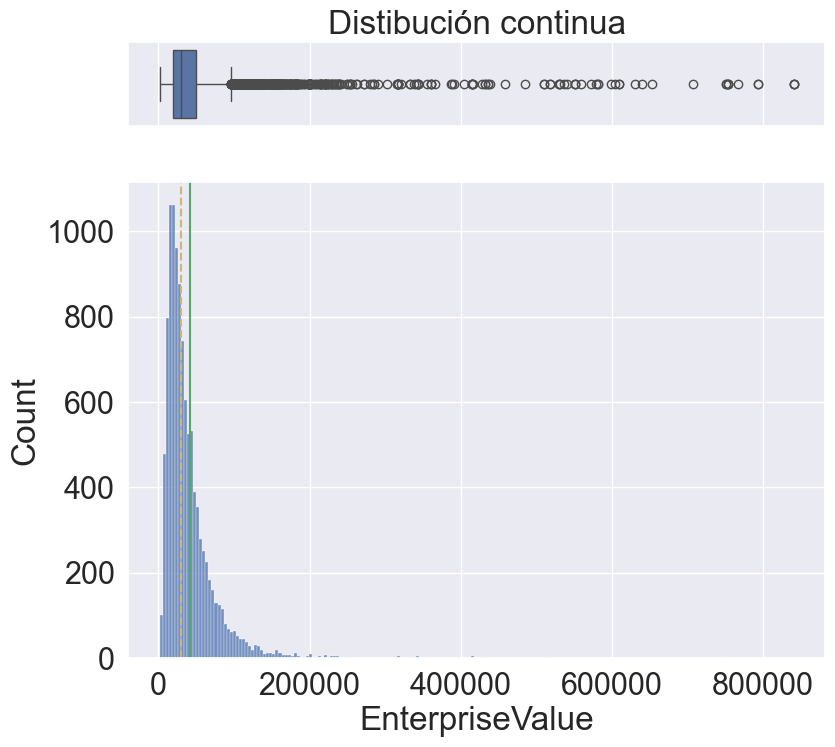

In [35]:
# Graficar
columna_a_graficar = 'EnterpriseValue' # indicar columna para el gráfico
plot(df_imputed[columna_a_graficar])

## Transformaciones

* Transformaciones logarítmicas:

In [36]:
columnas_a_transformar = [ 
    'CapExToRevenue',
    'DebtToEquity',
    'QuarterlyVariance_Lag1',
    'MarketCap',
    'EnterpriseValue'
    ]

df_transformed = transformar_log(
    df_imputed, 
    columnas_a_transformar, 
    calculo_1p=True
    )

# Coeficientes de asimetría actualizado
df_transformed.select_dtypes(include="number").skew().sort_values(ascending=False)

TrailingPE                              93.723241
RelativeRevenue                         71.212126
EnterpriseToEbitda                      48.527243
ReturnOnEquity                          42.855150
PriceToBook                             29.426778
CurrentDebt                             23.095351
TotalDebt                               17.993157
FinancingCashFlow_TTM                   11.891270
QuarterlyReturn_Lag1                    11.593843
EBITDA_TTM                              11.043350
NetIncome_TTM                           10.740257
EBITDA_TTM_QoQ                          10.370036
TotalRevenue_TTM_QoQ                     9.789767
OperatingIncome_TTM                      9.151986
OperatingCashFlow_TTM                    8.203045
ReturnOnAssets                           7.453040
FreeCashFlow_TTM_QoQ                     6.650900
GrossProfit_TTM                          5.698246
CurrentAssets                            5.544704
BasicAverageShares_TTM                   5.250610


## Tratamiento de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [37]:
# Definir columnas que saltean la "winsorización"
cols_fin_clean = obtener_cols_financieras(incluirTTM=True)

columnas_intactas = cols_fin_clean + [
    # Variables de precio y ratios
    'Close',
    'Open',    
    'TrailingPE',
    'EnterpriseToEbitda',
    'PriceToBook',
    # Otras
    'Date', 
    'Ticker'   
    ]

# Separar el dataset
df_passthrough = df_transformed[columnas_intactas].copy()
df_transformed_features = df_transformed.drop(columns=columnas_intactas)

In [38]:
df_transformed_features.info()

<class 'pandas.DataFrame'>
Index: 10793 entries, 8 to 11374
Data columns (total 36 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   Sector                                10793 non-null  category
 1   Industry                              10793 non-null  category
 2   FinancialsSource                      10793 non-null  str     
 3   YearsSinceAdded                       10793 non-null  float64 
 4   OperatingMargins                      10793 non-null  float64 
 5   ProfitMargins                         10793 non-null  float64 
 6   ReturnOnEquity                        10793 non-null  float64 
 7   ReturnOnAssets                        10793 non-null  float64 
 8   CurrentRatio                          10793 non-null  float64 
 9   NetDebtToEbitda                       10793 non-null  float64 
 10  FcfToEbitda                           10793 non-null  float64 
 11  AverageDailyVolume

In [39]:
# Outliers
df_cont_transformed = df_transformed_features.select_dtypes(include="number")
df_winsor = df_cont_transformed.apply(lambda x: gestiona_outliers(x, clas='winsor'))

In [40]:
# Coeficientes de asimetría luego de winsorizar
df_winsor.skew().sort_values(ascending=False)

RelativeRevenue                         1.747913
RelativeAssets                          1.675378
AverageDailyVolume_Lag1                 1.650390
ReturnOnEquity                          1.645884
QuarterlyVariance_Lag1_Log1p            1.631488
CapExToRevenue_Log1p                    1.630574
EBITDA_TTM_YoY                          1.620207
ReturnOnAssets                          1.604317
AverageDailyVolume_Lag1_YoY             1.538048
DebtToEquity_Log1p                      1.486734
NetDebtToEbitda                         1.472541
AverageDailyVolume_Lag1_QoQ             1.464900
YearsSinceAdded                         1.443678
TotalRevenue_TTM_YoY                    1.436553
CapitalExpenditure_TTM_Acceleration     1.384706
FreeCashFlow_TTM_YoY                    1.382148
CurrentRatio                            1.367410
QuarterlyReturn_Lag1                    1.300044
ProfitMargins                           1.021280
FcfToEbitda                             0.971576
OperatingMargins    

Cont


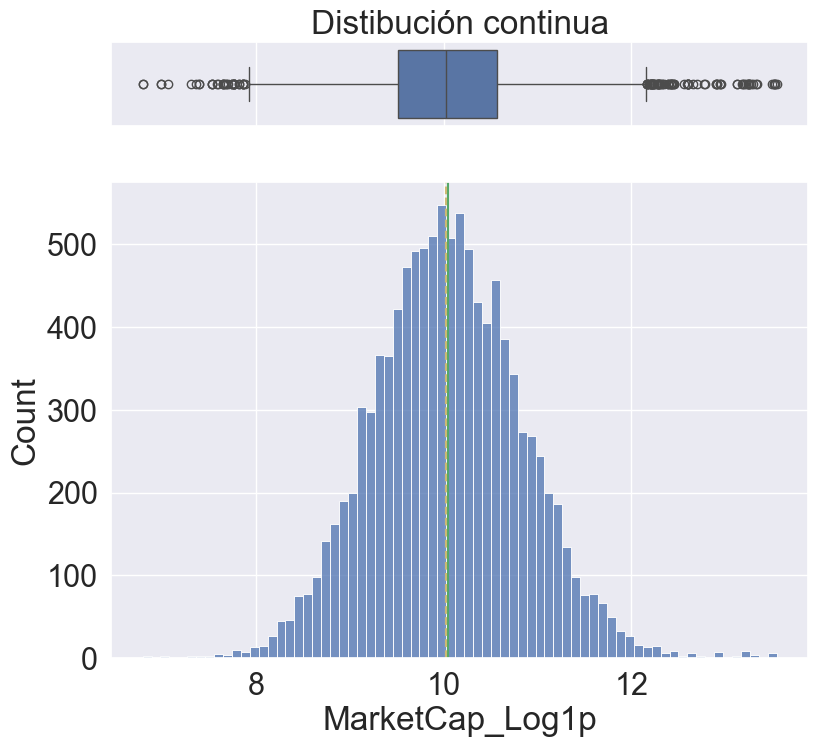

In [41]:
# Visualizar cambios
columna_a_graficar = 'MarketCap_Log1p' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [42]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
YearsSinceAdded,10793.0,15.047901,19.627335,0.000000,0.000000,7.000000,24.000000,69.000000
OperatingMargins,10793.0,0.146288,0.064969,-0.068613,0.099182,0.138506,0.181641,0.430169
ProfitMargins,10793.0,0.100630,0.053209,-0.127108,0.063900,0.093131,0.126352,0.314853
ReturnOnEquity,10793.0,0.281890,0.227207,-0.638058,0.132685,0.210838,0.347252,0.991215
ReturnOnAssets,10793.0,0.082925,0.059855,-0.099573,0.042916,0.066911,0.103936,0.287166
CurrentRatio,10793.0,1.547520,0.561287,0.317722,1.171285,1.433775,1.797223,3.675249
NetDebtToEbitda,10793.0,4.640009,4.714965,-11.066286,1.651870,3.175002,5.888246,18.627080
FcfToEbitda,10793.0,0.881974,0.639522,-1.317712,0.511913,0.760508,1.098315,2.860574
AverageDailyVolume_Lag1,10793.0,2.137988,1.579832,0.099728,1.077441,1.661075,2.657362,7.405051
TotalRevenue_TTM_YoY,10793.0,0.199733,0.606820,-0.908645,-0.187919,0.072743,0.413050,2.218169


## Concatenación Final y Almacenamiento

In [43]:
df_non_numeric_transformed = df_transformed_features.select_dtypes(exclude='number')
# Se unen variables contínuas transformadas y variables no numéricas
df_combined = pd.concat([df_non_numeric_transformed, df_winsor], axis=1)

# Unir con las columnas que fueron salteadas
df_final = pd.concat([df_passthrough, df_combined], axis=1)
df_final.info()

<class 'pandas.DataFrame'>
Index: 10793 entries, 8 to 11374
Data columns (total 63 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   CashAndCashEquivalents                10793 non-null  float64       
 1   CurrentDebt                           10793 non-null  float64       
 2   LongTermDebt                          10793 non-null  float64       
 3   TotalDebt                             10793 non-null  float64       
 4   StockholdersEquity                    10793 non-null  float64       
 5   TotalAssets                           10793 non-null  float64       
 6   CurrentAssets                         10793 non-null  float64       
 7   CurrentLiabilities                    10793 non-null  float64       
 8   OperatingCashFlow_TTM                 10793 non-null  float64       
 9   InvestingCashFlow_TTM                 10793 non-null  float64       
 10  FinancingCashF

In [44]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")
print(f"Fichero 'clean_data.parquet' guardado en la carpeta {data_folder}")

Fichero 'clean_data.parquet' guardado en la carpeta data
